Nama Lengkap : Nazarul Bagus Riyadi

NIM : 240401010229

Kelas : IF404

---

# Praktikum Pertemuan 11: Unsupervised Learning — Clustering


## Import Library


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

print('Library berhasil diimport')


Library berhasil diimport


## Langkah 1: Generate & Eksplorasi Dataset

Dataset sintetis 300 pelanggan dengan **tiga kelompok tersembunyi** (hemat, menengah, boros) pada pendapatan tahunan dan skor belanja.


Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


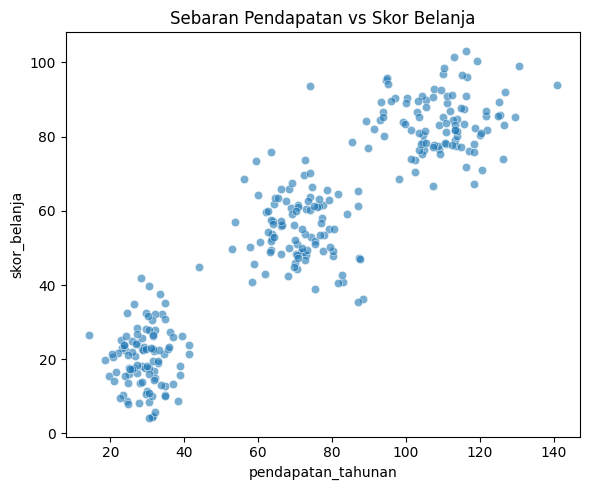

In [2]:
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))    # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))   # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))  # boros
data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.tight_layout()
plt.show()


## Langkah 2: Preprocessing Data

Clustering memakai jarak, jadi `pendapatan_tahunan` dan `skor_belanja` di-scale. `usia` dan `gender` tidak dipakai — modul menandai encoding gender sebagai opsional, dan kedua fitur itu tidak membentuk kelompok tersembunyi.


In [3]:
X = df[['pendapatan_tahunan', 'skor_belanja']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling     :', X_scaled.std(axis=0).round(3))


Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling     : [1. 1.]


## Langkah 3: Metode Elbow untuk Menentukan K

K-Means dijalankan untuk K = 1 sampai 10. Titik elbow = K di mana penurunan WCSS mulai melandai.


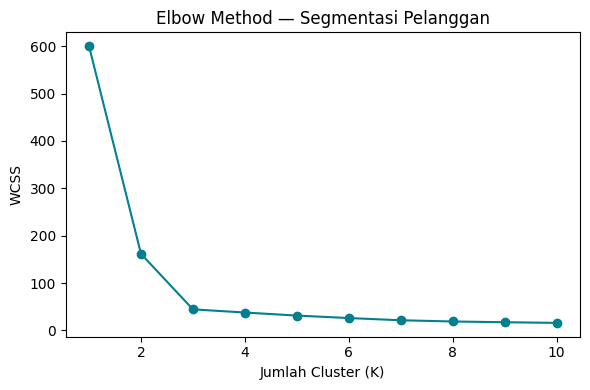

 K  WCSS
 1 600.0
 2 161.7
 3  44.6
 4  37.9
 5  31.4
 6  26.2
 7  21.6
 8  19.0
 9  17.4
10  16.0


In [4]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'K': range(1, 11), 'WCSS': np.round(wcss, 1)}).to_string(index=False))


### Interpretasi Elbow

Kurva turun tajam sampai **K = 3**, lalu mulai landai. Itu sesuai tiga kelompok yang disuntikkan saat generate data. Silhouette Score di langkah berikutnya dipakai sebagai pembanding yang lebih objektif.


## Langkah 4: Melatih Model K-Means

K = 3 dari Elbow. Tampilkan WCSS, Silhouette Score, dan rata-rata fitur per cluster.


In [5]:
print('Silhouette Score per K:')
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    labels = km.fit_predict(X_scaled)
    print(f'  K={k}: {silhouette_score(X_scaled, labels):.3f}')

model = KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=10)
model.fit(X_scaled)
df['cluster'] = model.labels_

print()
print(f'WCSS akhir      : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print()
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))
print()
print('Jumlah anggota per cluster:')
print(df['cluster'].value_counts().sort_index())


Silhouette Score per K:
  K=2: 0.634
  K=3: 0.695


  K=4: 0.580


  K=5: 0.481
  K=6: 0.381
  K=7: 0.394

WCSS akhir      : 44.556
Silhouette Score: 0.695

         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08

Jumlah anggota per cluster:
cluster
0     99
1    100
2    101
Name: count, dtype: int64


## Langkah 5: Visualisasi Hasil Clustering

Scatter per cluster + centroid (dikembalikan ke skala asli).


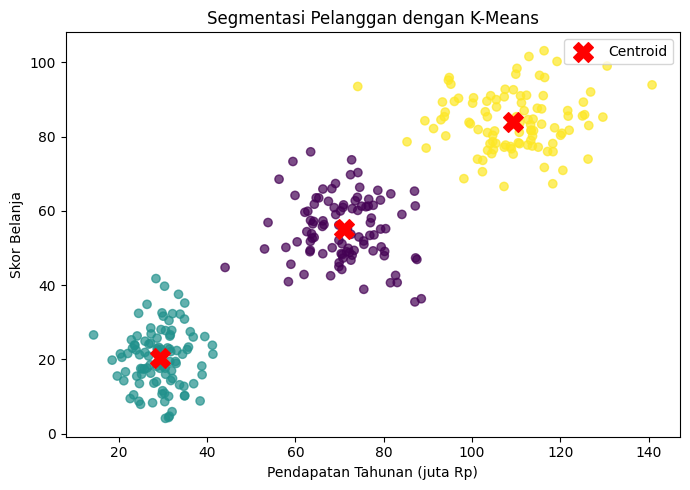

Posisi centroid (skala asli):
   pendapatan_tahunan  skor_belanja
0               70.99         55.05
1               29.31         20.27
2              109.20         84.08


In [6]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(
    df['pendapatan_tahunan'], df['skor_belanja'],
    c=df['cluster'], cmap='viridis', alpha=0.7
)
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    c='red', marker='X', s=200, label='Centroid'
)
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend()
plt.tight_layout()
plt.show()

print('Posisi centroid (skala asli):')
print(pd.DataFrame(centroids, columns=['pendapatan_tahunan', 'skor_belanja']).round(2))


### Interpretasi segmen

Label cluster dari K-Means tidak berurutan 0–1–2 sesuai “hemat → boros”. Baca dari rata-rata fitur:

- Pendapatan rendah + belanja rendah → segmen **Hemat**
- Pendapatan menengah + belanja menengah → segmen **Menengah**
- Pendapatan tinggi + belanja tinggi → segmen **Boros / Premium**


## Langkah 6: Hierarchical Clustering (Pembanding)

Dendrogram Ward linkage. Garis potong horizontal memotong 3 cabang utama jika struktur data konsisten dengan Elbow.


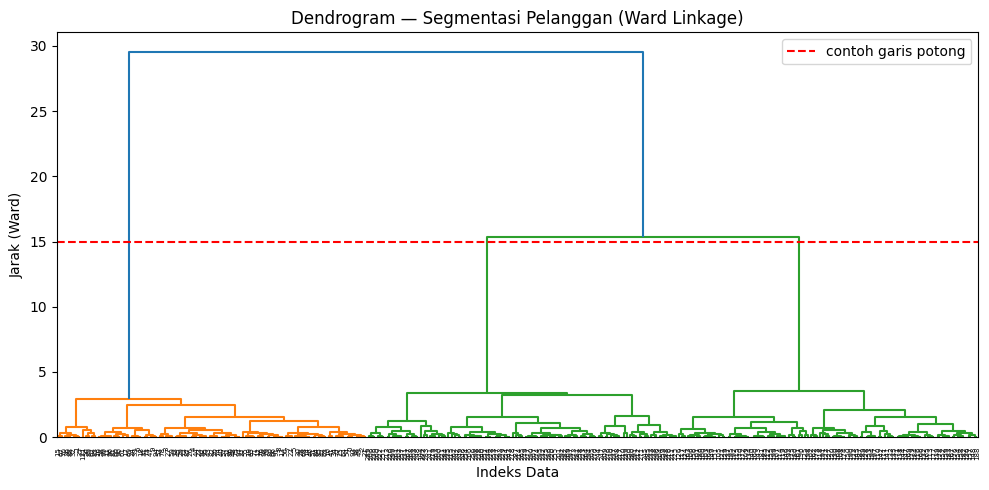

In [7]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data')
plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--', label='contoh garis potong')
plt.legend()
plt.tight_layout()
plt.show()


### Bandingkan dengan K-Means

Tiga cabang besar di dendrogram selaras dengan K = 3 dari Elbow. Hierarchical tidak butuh K di awal, tetapi K-Means lebih mudah dipakai ulang untuk pelanggan baru (tinggal `predict` ke centroid).


## Kesimpulan

### Apa yang Dipelajari
- Clustering adalah Unsupervised Learning: tidak ada label y, model mencari kelompok sendiri
- K-Means + Elbow untuk memilih K, Silhouette Score sebagai pembanding
- Hierarchical clustering (Ward) lewat dendrogram, tanpa menentukan K di awal
- Scaling wajib karena clustering berbasis jarak

### Temuan Utama
- Elbow: WCSS jatuh dari 161.7 (K=2) ke 44.6 (K=3), lalu hanya ke 37.9 (K=4) — siku di K = 3
- Silhouette tertinggi di K = 3 (0.695), lebih baik dari K = 2 (0.634) dan K = 4 (0.580)
- Segmen: Hemat (~29 juta, skor 20), Menengah (~71 juta, skor 55), Boros/Premium (~109 juta, skor 84)
- Dendrogram Ward memotong 3 cabang utama — konsisten dengan K-Means

### Keterbatasan
- Dataset sintetis, kelompoknya sengaja dibuat terpisah; data pelanggan nyata biasanya lebih overlap
- Hanya dua fitur yang dipakai; usia dan gender diabaikan
- K-Means mengasumsikan cluster berbentuk bulat — tidak cocok untuk semua bentuk sebaran
